## Imports

In [1]:
import cv2 as cv # OpenCV (Open Source Computer Vision Library) 
import numpy as np
import matplotlib.pyplot as plt

import Functions as func
import Vis as vis
import CompVis as comp_vis
from scipy.interpolate import make_interp_spline

%load_ext autoreload
%autoreload 2

### fixed variables

In [2]:
nPC = 8
reduction_factor = 0.2
out_video_path = 'out/'
nframes = 800
fps = 240

### Inspec one day

In [ ]:
dataset = comp_vis.load_grayscale_dataset(out_video_path + in_video_path.split('/')[-1])
H, W, V = comp_vis.compute_pca(dataset)

In [ ]:
comp_vis.get_num_components_for_variance(V, 90)

In [ ]:
vis.plot_pca_eigenvalues_with_threshold(V, 90)

### Inspec over time

In [3]:
names = ['videos/8days/20260207/240/VID_20260207_081701560.mp4', 
         'videos/8days/20260208/240/VID_20260208_071551134.mp4',
         'videos/8days/20260209/240/VID_20260209_075208490.mp4',
         'videos/8days/20260210/240/VID_20260210_073714886.mp4',
         'videos/8days/20260211/240/VID_20260211_072715346.mp4',
         'videos/8days/20260212/240/VID_20260212_072409310.mp4',
         'videos/8days/20260213/240/VID_20260213_073426768.mp4',
         'videos/8days/20260214/240/VID_20260214_040340493.mp4']

In [51]:
rois = [(25, 148, 631, 819),
        (12, 169, 689, 814),
        (10, 132, 680, 823),
        (10, 89, 699, 851),
        (6, 125, 689, 804),
        (5, 146, 670, 785),
        (10, 120, 680, 830),
        (8, 112, 687, 800)]

In [52]:
for i, (name, roi) in enumerate(zip(names, rois)):
    print(f'{name} processing...', end = ' ')
    comp_vis.pre_processing(name, out_video_path + name.split('/')[-1], nframes, fps, reduction_factor, roi)
    print(f'done.')

videos/8days/20260207/240/VID_20260207_081701560.mp4 processing... done.
videos/8days/20260208/240/VID_20260208_071551134.mp4 processing... done.
videos/8days/20260209/240/VID_20260209_075208490.mp4 processing... done.
videos/8days/20260210/240/VID_20260210_073714886.mp4 processing... done.
videos/8days/20260211/240/VID_20260211_072715346.mp4 processing... done.
videos/8days/20260212/240/VID_20260212_072409310.mp4 processing... done.
videos/8days/20260213/240/VID_20260213_073426768.mp4 processing... done.
videos/8days/20260214/240/VID_20260214_040340493.mp4 processing... done.


### PCA over time

In [5]:
results = []
for name in names:
    dataset = comp_vis.load_grayscale_dataset(out_video_path + name.split('/')[-1])
    H, W, V = comp_vis.compute_pca(dataset)
    results.append(comp_vis.get_num_components_for_variance(V, 90))


In [7]:
print(results)
print(np.mean(results))

[13, 7, 10, 9, 10, 12, 11, 10]
10.25


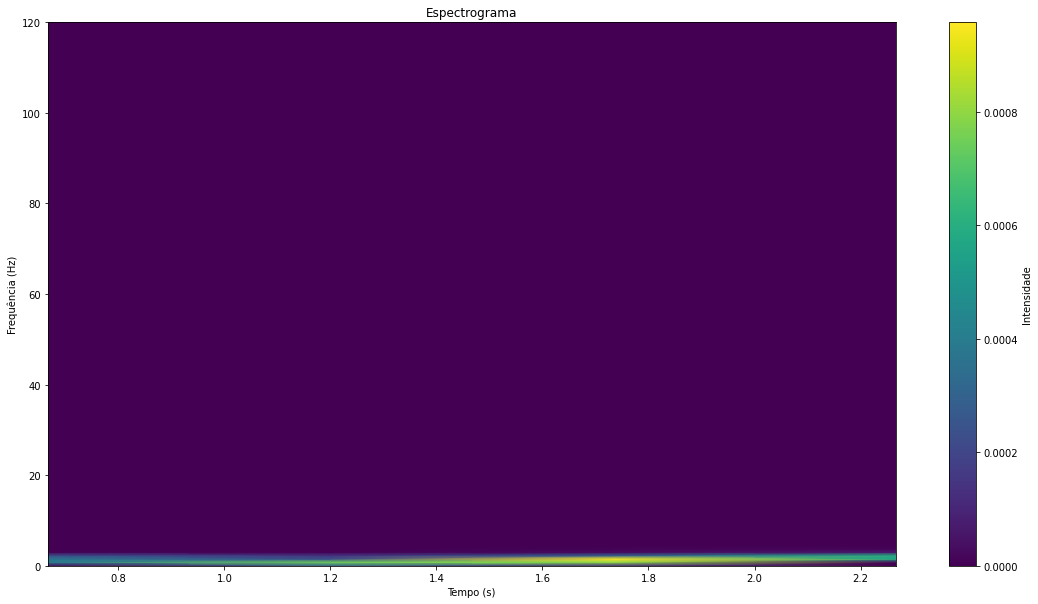

<Figure size 432x288 with 0 Axes>

In [21]:
from scipy.signal import spectrogram
import matplotlib.pyplot as plt

fs = 240 # fps do vídeo

f, t, Sxx = spectrogram(
    unmixed[:, 1],
    fs=fs,
    window='hann',
    nperseg=320,
    noverlap=192
)
plt.figure(figsize = [19, 10])
plt.pcolormesh(t, f, Sxx, shading='gouraud')
plt.ylabel("Frequência (Hz)")
plt.xlabel("Tempo (s)")
plt.title("Espectrograma")
plt.colorbar(label="Intensidade")
plt.show()
plt.savefig('out/spect.png', bbox_inches = 'tight')